In [578]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

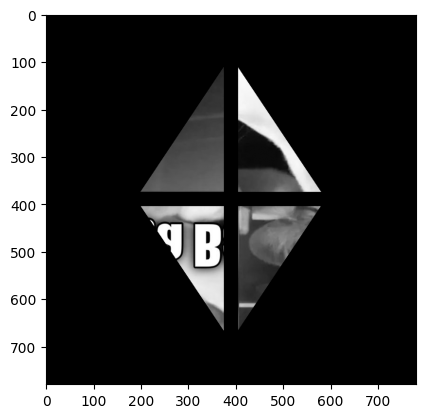

In [579]:
citra01 = cv.imread("Assets/citra1.PNG", cv.IMREAD_GRAYSCALE)
plt.imshow(citra01, cmap='gray')

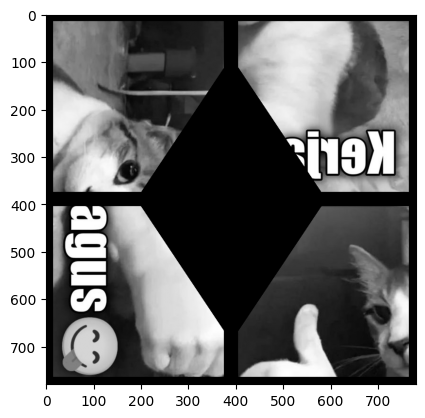

In [580]:
citra02 = cv.imread("Assets/citra2.PNG",cv.IMREAD_GRAYSCALE)
plt.imshow(citra02, cmap= "gray")

In [581]:
def fungsi_empat_R(image, val):
    h, w = image.shape
    val = int(val) % 360
    if val == 0: return image
    elif val == 90:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[j, h - 1 - i] = image[i, j]
        return rot
    elif val == 180:
        rot = np.zeros_like(image, dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[h - 1 - i, w - 1 - j] = image[i, j]
        return rot 
    elif val == 270:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[w - 1 - j, i] = image[i, j]
        return rot
    return image

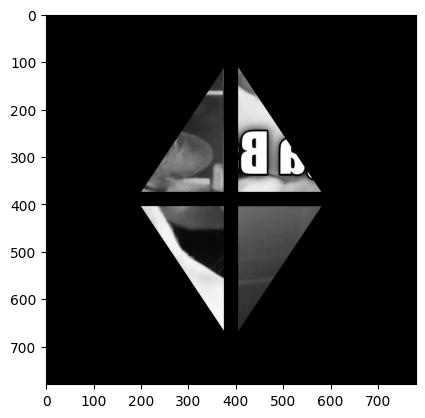

In [582]:
rot1 = fungsi_empat_R(citra01, 180)
plt.imshow(rot1,cmap='gray')

In [583]:
#tipe a: penyatuan ruang (tumpuk/blending) 
def fungsi_dua_a(citra_1, citra_2): 
    return citra_1 + citra_2 
 
#tipe b: penyatuan sumbu horizontal (kiri-kanan) 
def fungsi_dua_b(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    hasil = np.zeros((tinggi, lebar)).astype(int) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil 
 
#tipe c: penyatuan sumbu vertikal (atas-bawah) 
def fungsi_dua_c(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    hasil = np.zeros((tinggi, lebar)).astype(int) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2 
    return hasil 

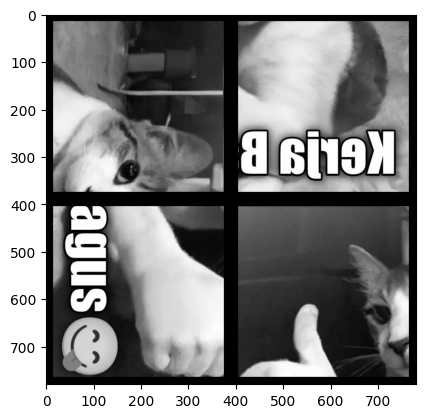

In [584]:
hasil_gabung = fungsi_dua_a(rot1, citra02)
plt.imshow(hasil_gabung, cmap='gray')

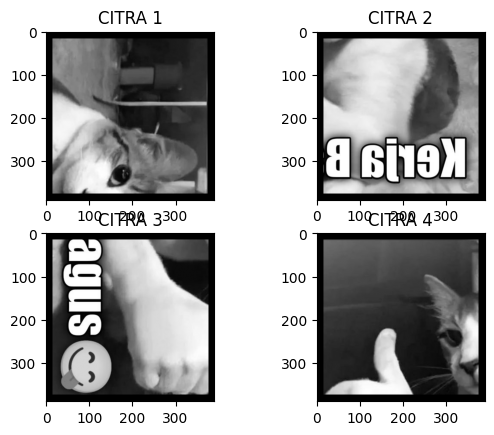

In [585]:
gambar1 = hasil_gabung[0:390,0:390]
plt.subplot(2 ,2 ,1)
plt.title("CITRA 1")
plt.imshow(gambar1,cmap='gray')
gambar2 = hasil_gabung[0:390,390:780]
plt.subplot(2 ,2 ,2)
plt.title("CITRA 2")
plt.imshow(gambar2,cmap='gray')
gambar3 = hasil_gabung[390:780,0:390]
plt.subplot(2 ,2 ,3)
plt.title("CITRA 3")
plt.imshow(gambar3,cmap='gray')
gambar4 = hasil_gabung[390:780,390:780]
plt.subplot(2 ,2 ,4)
plt.title("CITRA 4")
plt.imshow(gambar4,cmap='gray')

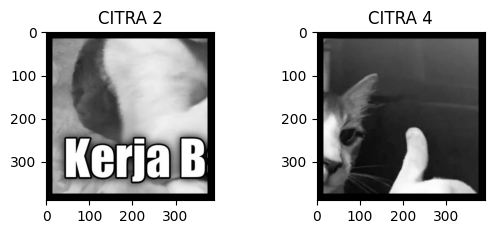

In [586]:
def fungsi_flip(image, mode='H'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            if mode == 'H':
                hasil[i, j] = image[i, w - 1 - j]
            elif mode == 'V':
                hasil[i, j] = image[h - 1 - i, j]
    return hasil

gambar2_f = fungsi_flip(gambar2,'H')
plt.subplot(2 ,2 ,1)
plt.title("CITRA 2")
plt.imshow(gambar2_f,cmap='gray')

gambar4_f = fungsi_flip(gambar4,'H')
plt.subplot(2 ,2 ,2)
plt.title("CITRA 4")
plt.imshow(gambar4_f,cmap='gray')

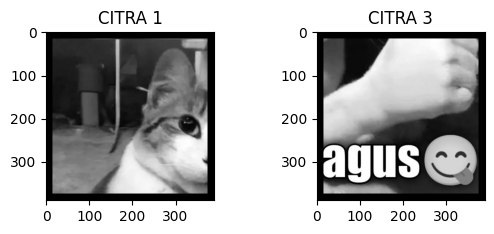

In [587]:
gambar1_r = fungsi_empat_R(gambar1, 270)
plt.subplot(2 ,2 ,1)
plt.title("CITRA 1")
plt.imshow(gambar1_r,cmap='gray')
gambar3_r = fungsi_empat_R(gambar3, 270)
plt.subplot(2 ,2 ,2)
plt.title("CITRA 3")
plt.imshow(gambar3_r,cmap='gray')

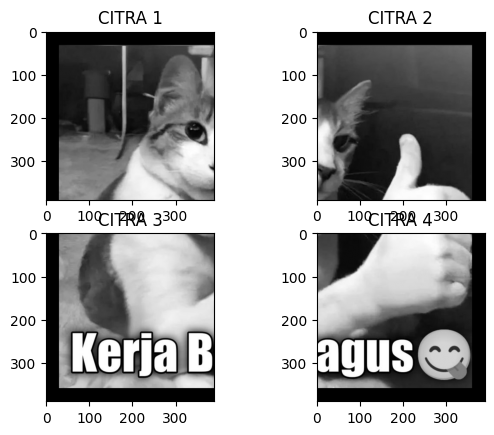

In [588]:
def fungsi_lima(image, geser_kolom_x=0, geser_baris_y=0): 
    image = np.array(image) 
    h, w = image.shape 
    hasil = np.zeros((h, w), dtype=image.dtype) 
    for i in range(h): 
        for j in range(w): 
            new_i = i + geser_baris_y 
            new_j = j + geser_kolom_x 
            if 0 <= new_i < h and 0 <= new_j < w: 
                hasil[new_i, new_j] = image[i, j] 
    return hasil

gambar1_tr = fungsi_lima(gambar1_r,15,15)
plt.subplot(2 ,2 ,1)
plt.title("CITRA 1")
plt.imshow(gambar1_tr,cmap='gray')
gambar2_tr = fungsi_lima(gambar4_f, -15,15)
plt.subplot(2 ,2 ,2)
plt.title("CITRA 2")
plt.imshow(gambar2_tr,cmap='gray')
gambar3_tr = fungsi_lima(gambar2_f, 15,-15)
plt.subplot(2 ,2 ,3)
plt.title("CITRA 3")
plt.imshow(gambar3_tr,cmap='gray')
gambar4_tr = fungsi_lima(gambar3_r,-15,-15)
plt.subplot(2 ,2 ,4)
plt.title("CITRA 4")
plt.imshow(gambar4_tr,cmap='gray')

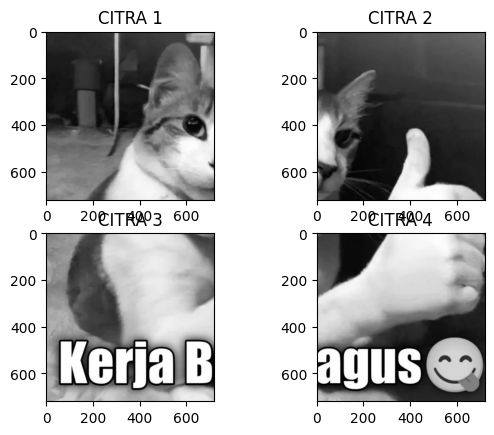

In [589]:
def fungsi_tiga(image, p1, p2, p3, p4): 
    h, w = image.shape 
    # skala 2x lipat 
    dilated = np.zeros((h * 2, w * 2)).astype(int) 
    for y in range(h * 2): 
        for x in range(w * 2): 
            dilated[y][x] = image[int(y / 2)][int(x / 2)] 
    # normalisasi (crop) sisi luar 
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2) 
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4) 
    return dilated[sy:ey, sx:ex]

gambar1_dt = fungsi_tiga(gambar1_tr, 60, 0, 60, 0)
plt.subplot(2 ,2 ,1)
plt.title("CITRA 1")
plt.imshow(gambar1_dt,cmap='gray')
gambar2_dt = fungsi_tiga(gambar2_tr, 60,0 , 0, 60)
plt.subplot(2 ,2 ,2)
plt.title("CITRA 2")
plt.imshow(gambar2_dt,cmap='gray')
gambar3_dt = fungsi_tiga(gambar3_tr, 0, 60, 60, 0)
plt.subplot(2 ,2 ,3)
plt.title("CITRA 3")
plt.imshow(gambar3_dt,cmap='gray')
gambar4_dt = fungsi_tiga(gambar4_tr, 0, 60, 0, 60)
plt.subplot(2 ,2 ,4)
plt.title("CITRA 4")
plt.imshow(gambar4_dt,cmap='gray')

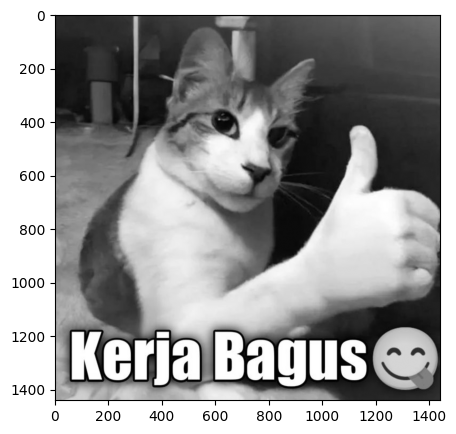

In [590]:
gambar_m1 = fungsi_dua_b(gambar1_dt, gambar2_dt)

gambar_m2 = fungsi_dua_b(gambar3_dt, gambar4_dt)

gambar_m = fungsi_dua_c(gambar_m1,gambar_m2)

plt.figure(figsize=(5,5))
plt.imshow(gambar_m, cmap='gray')

In [ ]:
def hist(image):
    kanvas = [0] * 256
    h = len(image)
    w = len(image[0])
    for i in range(h):
        for j in range(w):
            value = int(image[i][j])
            if value < 0:
                value = 0
            elif value > 255:
                value = 255
            kanvas[value] += 1
    return kanvas

def histnormal(image):
    h = len(image)
    w = len(image[0])
    
    img_min = image[0][0]
    img_max = image[0][0]
    for i in range(h):
        for j in range(w):
            if image[i][j] < img_min:
                img_min = image[i][j]
            if image[i][j] > img_max:
                img_max = image[i][j]
    
    normalized = [[0] * w for _ in range(h)]
    for i in range(h):
        for j in range(w):
            if img_max != img_min:
                normalized[i][j] = int((image[i][j] - img_min) / (img_max - img_min) * 255)
            else:
                normalized[i][j] = 0
    
    kanvas = [0] * 256
    for i in range(h):
        for j in range(w):
            value = normalized[i][j]
            if value < 0: value = 0
            elif value > 255: value = 255
            kanvas[value] += 1

    return kanvas

def bagi_citra(image, pembagi):
    h = len(image)
    w = len(image[0])
    hasil = [[0] * w for _ in range(h)]
    for i in range(h):
        for j in range(w):
            hasil[i][j] = int(image[i][j] / pembagi)
    return hasil

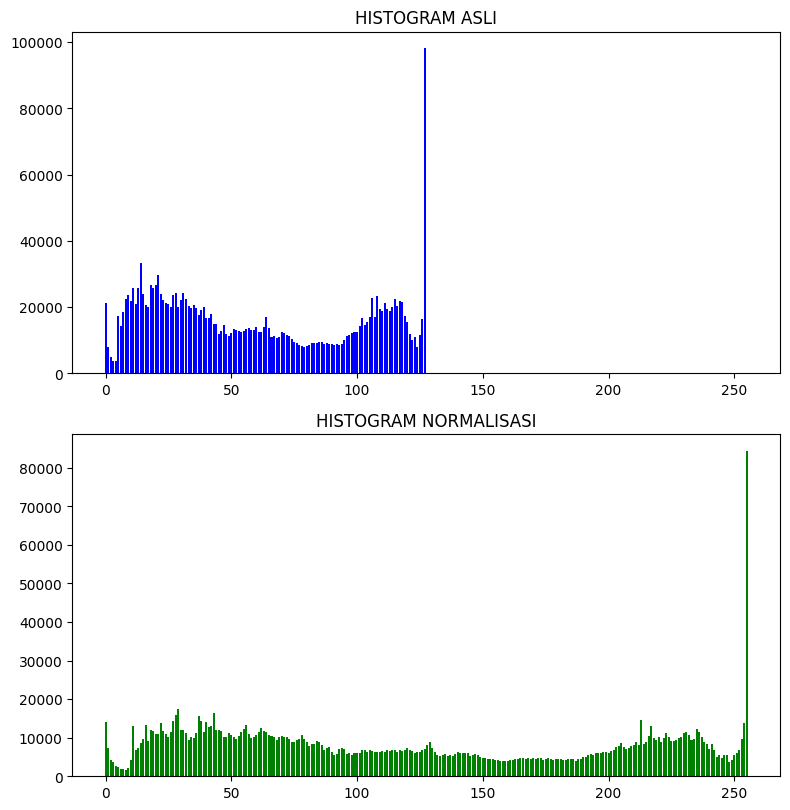

In [625]:
hist_asli = hist(gambar_m)
gambar_dibagi = bagi_citra(gambar_m, 2)
normal = hist(gambar_dibagi)
hist_norm = histnormal(gambar_dibagi)

x = range(256)
plt.figure(figsize=(8, 12))

# Subplot 1: ASLI
plt.subplot(3, 1, 1)
plt.title("HISTOGRAM ASLI")
plt.bar(x, hist(gambar_dibagi), color='blue')


plt.subplot(3, 1, 2)
plt.title("HISTOGRAM NORMALISASI")
plt.bar(x, hist(gambar_m), color='green')

plt.tight_layout()
plt.show()

In [627]:
def konvolusi_clipping(image, kernel):
    h = len(image)
    w = len(image[0])
    
    padded = [[0] * (w + 4) for _ in range(h + 4)]
    for i in range(h):
        for j in range(w):
            padded[i+2][j+2] = image[i][j]
            
    hasil = [[0] * w for _ in range(h)]
    for i in range(h):
        for j in range(w):
            nilai = 0
            for ki in range(4):
                for kj in range(4):
                    nilai += padded[i+ki+1][j+kj+1] * kernel[ki][kj]
            
            nilai_akhir = int(nilai)
            if nilai_akhir < 0:
                nilai_akhir = 0
            elif nilai_akhir > 255:
                nilai_akhir = 255
            hasil[i][j] = nilai_akhir
            
    return hasil

def dapatkan_gambar_normal(image):
    h = len(image)
    w = len(image[0])
    img_min = image[0][0]
    img_max = image[0][0]
    for i in range(h):
        for j in range(w):
            if image[i][j] < img_min: img_min = image[i][j]
            if image[i][j] > img_max: img_max = image[i][j]
    
    res = [[0] * w for _ in range(h)]
    for i in range(h):
        for j in range(w):
            if img_max != img_min:
                res[i][j] = int((image[i][j] - img_min) / (img_max - img_min) * 255)
            else:
                res[i][j] = 0
    return res

kernel_kicau = [
    [-0.1, -0.1, -0.1, -0.1],
    [-0.1,  0.4,  0.4, -0.1],
    [-0.1,  0.4,  0.4, -0.1],
    [-0.1, -0.1, -0.1, -0.1]
]


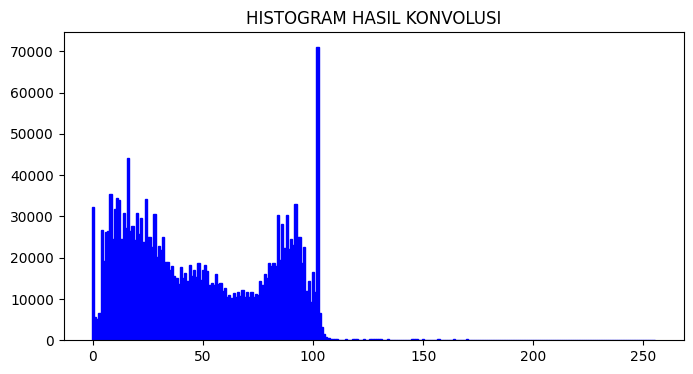

In [628]:
gambar_siap_konv = dapatkan_gambar_normal(gambar_dibagi)
gambar_akhir = konvolusi_clipping(gambar_siap_konv, kernel_kicau)
hist_akhir = hist(gambar_akhir)

plt.figure(figsize=(8, 4))
plt.title("HISTOGRAM HASIL KONVOLUSI")
plt.bar(x, hist_akhir, color='blue', width=1.0, edgecolor='blue')
plt.show()

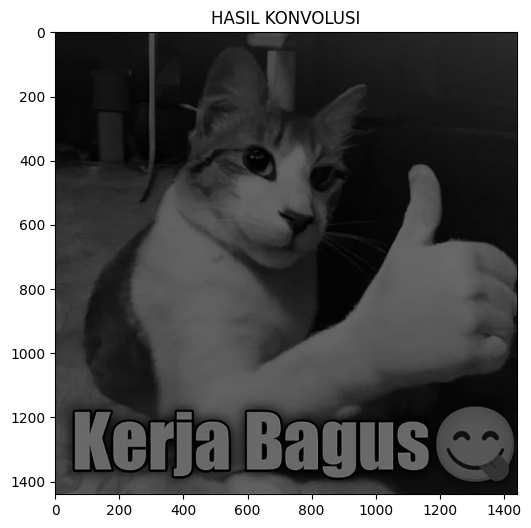

In [629]:
plt.figure(figsize=(6, 6))
plt.title("HASIL KONVOLUSI")
plt.imshow(gambar_akhir, cmap='gray')
plt.show()

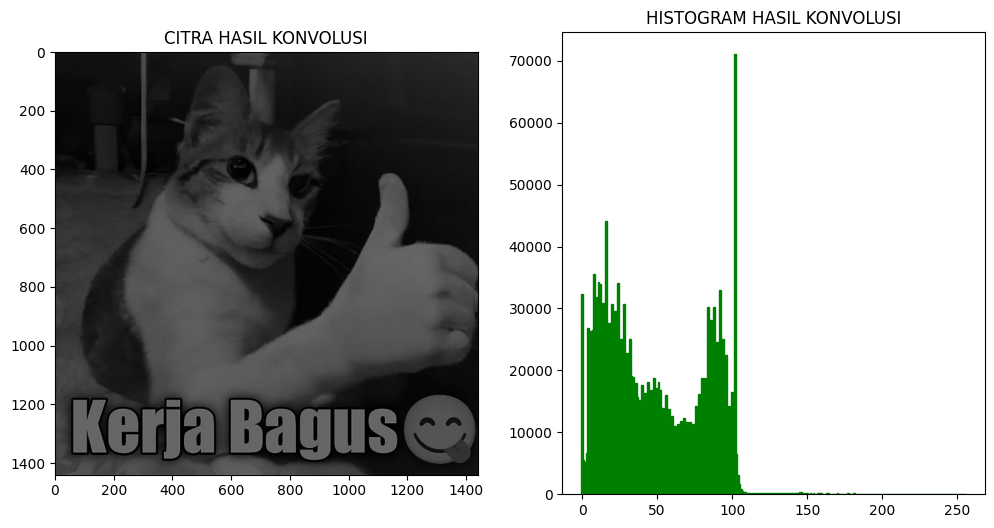

In [630]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("CITRA HASIL KONVOLUSI")
plt.imshow(gambar_akhir, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 2, 2)
plt.title("HISTOGRAM HASIL KONVOLUSI")
plt.bar(x, hist_akhir, color='green', width=1.0, edgecolor='green')

plt.show()

In [ ]:
# Analisis
pengaruh terhadap citra dari proses padding, konvolusi, dan clipping
Sebelum proses konvolusi dijalankan, citra dulu dikasih padding intinya nambah bingkai kosong bernilai 0 (hitam) sebesar 2 piksel di setiap sisinya. Kenapa perlu, Karena kalau langsung dikonvolusi tanpa padding, piksel-piksel yang ada di pinggir citra bakal kekurangan tetangga saat kernel 4x4 digeser-geser di atasnya. Dengan padding, semua piksel termasuk yang di sudut sekalipun bisa ikut dihitung dengan lengkap, dan ukuran citra output tetap sama seperti inputnya.
Setelah itu baru masuk ke tahap konvolusi pakai kernel_kicau. Kalau dilihat bentuk kernelnya, bagian tengah punya nilai positif (0.4) dan bagian tepinya negatif (-0.1). Pola seperti ini efeknya adalah sharpening atau penajaman piksel yang nilainya beda jauh dari tetangganya (alias area tepi/kontur) bakal makin ditonjolkan, sedangkan area yang rata dan seragam cenderung diredam. Jadi secara visual, citra hasil konvolusi bakal keliatan lebih tegas di bagian pinggir objeknya.
Nah, masalahnya setelah operasi perkalian dan penjumlahan kernel itu, hasilnya bisa meleset keluar dari rentang normal 0-255 bisa minus, bisa juga lebih dari 255. Di sinilah clipping berperan. Nilai yang kurang dari 0 langsung dipaksa jadi 0 (hitam), dan yang lebih dari 255 dipaksa jadi 255 (putih). Tanpa clipping, nilai-nilai aneh itu bakal bikin tampilan citra kacau karena sistem grayscale cuma mengenal angka di rentang itu. Jadi clipping ini semacam pengaman terakhir biar output-nya tetap valid dan bisa ditampilkan dengan benar.

SyntaxError: invalid syntax (1582072613.py, line 2)